# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [5]:
import sys, os
#if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
#    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
#    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
#if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#    !bash ../xvfb start
#    os.environ['DISPLAY'] = ':1'

In [6]:
# Install gymnasium if you didn't
#!pip install "gymnasium[toy_text,classic_control]"

/home/Vlad/share/Practical_RL/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) [error.pcm] unable to open slave


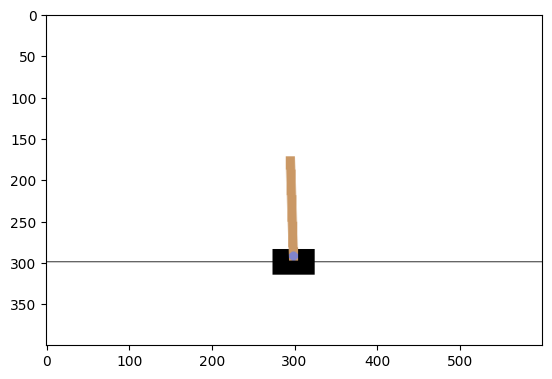

In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [8]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [9]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [10]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 2.6470413e-02 -2.4261633e-02 -2.6321236e-02 -6.2934845e-04]
 [ 2.5985181e-02  1.7122772e-01 -2.6333824e-02 -3.0149937e-01]
 [ 2.9409736e-02  3.6671492e-01 -3.2363810e-02 -6.0236973e-01]
 [ 3.6744036e-02  5.6227422e-01 -4.4411205e-02 -9.0506840e-01]
 [ 4.7989517e-02  3.6778095e-01 -6.2512577e-02 -6.2666875e-01]]
actions: [1, 1, 1, 0, 0]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [11]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_indices = [i for i, r in enumerate(rewards_batch) if r > reward_threshold]

    elite_states = [state for i in elite_indices for state in states_batch[i]]
    elite_actions = [action for i in elite_indices for action in actions_batch[i]]
 
    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [12]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 431.140, threshold=524.000


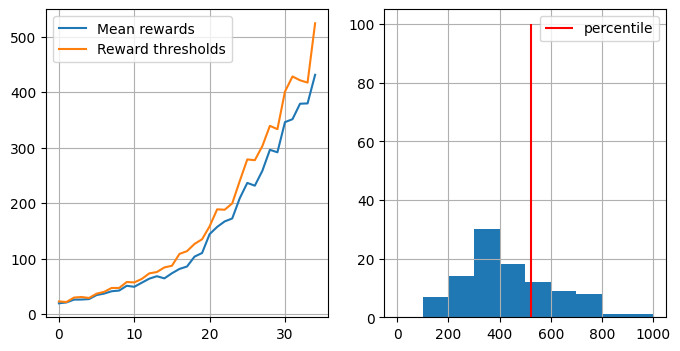

You Win! You may stop training now via KeyboardInterrupt.


In [13]:
n_sessions = 100
percentile = 70
log = []
n = 0

for i in range(100):
    # generate new sessions
    sessions = [ generate_session(env, agent, t_max=1000) for _ in range(n_sessions) ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions)
    
    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        n += 1
        print("You Win! You may stop training now via KeyboardInterrupt.")
        if n > 10:
            break

    

# Results

In [14]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/home/Vlad/share/Practical_RL/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/home/Vlad/share/Practical_RL/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/Vlad/share/Practical_RL/week01_intro/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) [error.pcm] unable to open slave


In [15]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [53]:
env = gym.make("LunarLander-v3").env
env.reset()

state_dim = env.observation_space.shape[0]  # 8
n_actions = env.action_space.n  # 4

print(f"state_dim = {state_dim}, n_actions = {n_actions}")
print(f"State space: {env.observation_space}")
print(f"Action space: {env.action_space}")

state_dim = 8, n_actions = 4
State space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


In [ ]:
agent = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64),
    activation='relu',
    max_iter=150,
    alpha=0.01,
    learning_rate_init=0.001
)

initial_state, _ = env.reset()
agent.partial_fit([initial_state] * n_actions, range(n_actions), classes=range(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.01
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [55]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game.
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()
    
    for t in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(n_actions, p=probs)
        
        new_s, r, terminated, truncated, _ = env.step(a)
        
        states.append(s)
        actions.append(a)
        total_reward += r
        
        s = new_s
        if terminated or truncated:
            break
            
    return states, actions, total_reward

mean reward = 51.773, threshold=39.184


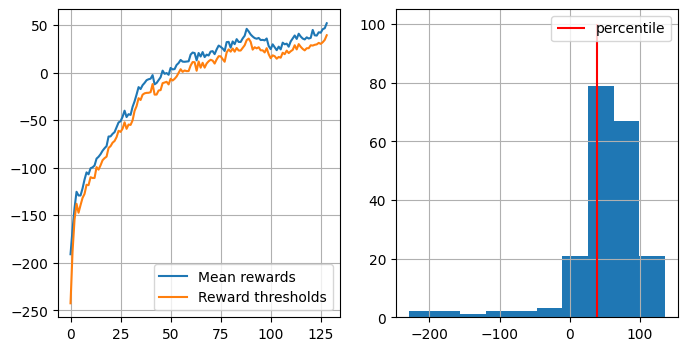

Success at iteration 128! Mean reward: 51.773


In [ ]:
n_sessions = 200
percentile = 30
log = []

print("Starting training for LunarLander...")
print("Target: average reward >= 50")

for i in range(200):
    sessions = [generate_session(env, agent, t_max=1000) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[np.min(rewards_batch), np.max(rewards_batch)]
    )
    
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    
    if i % 10 == 0:
        print(f"Iteration {i}: mean reward = {mean_reward:.3f}, threshold = {threshold:.3f}")

    if mean_reward > 50:
        print(f"Success at iteration {i}! Mean reward: {mean_reward:.3f}")
        break

In [61]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("LunarLander-v3", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/home/Vlad/share/Practical_RL/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/Vlad/share/Practical_RL/week01_intro/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [62]:

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


In [ ]:
env = gym.make("LunarLander-v3").env
env.reset()

state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

print(f"state_dim = {state_dim}, n_actions = {n_actions}")
print(f"State space: {env.observation_space}")
print(f"Action space: {env.action_space}")

state_dim = 8, n_actions = 4
State space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


In [ ]:
agent = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64),
    activation='relu',
    max_iter=150,
    alpha=0.01,
    learning_rate_init=0.001
)

initial_state, _ = env.reset()
agent.partial_fit([initial_state] * n_actions, range(n_actions), classes=range(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.01
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [ ]:
from joblib import Parallel, delayed

n_sessions = 100
percentile = 30
log = []

recent_sessions_history = []

print("Training with acceleration...")

for i in range(500):
    sessions = Parallel(n_jobs=-1)(
        delayed(generate_session)(env, agent, t_max=1000) 
        for _ in range(n_sessions)
    )
    

    recent_sessions_history.append(sessions)

    if len(recent_sessions_history) > 3:
        recent_sessions_history.pop(0)

    all_sessions = [s for batch in recent_sessions_history for s in batch]
    
    states_batch, actions_batch, rewards_batch = zip(*all_sessions)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )
    
    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions)

    mean_reward = np.mean(rewards_batch[-n_sessions:])
    print(f"Iteration {i}: mean reward = {mean_reward:.3f}")
    
    if mean_reward > 50:
        print(f"Success! Mean reward: {mean_reward:.3f}")
        break

Training with acceleration...
Iteration 0: mean reward = -256.562
Iteration 1: mean reward = -234.460
Iteration 2: mean reward = -207.312
Iteration 3: mean reward = -233.341
Iteration 4: mean reward = -205.402
Iteration 5: mean reward = -170.842
Iteration 6: mean reward = -147.377
Iteration 7: mean reward = -146.230
Iteration 8: mean reward = -132.063
Iteration 9: mean reward = -122.623
Iteration 10: mean reward = -121.523
Iteration 11: mean reward = -109.617
Iteration 12: mean reward = -108.282
Iteration 13: mean reward = -113.077
Iteration 14: mean reward = -113.111
Iteration 15: mean reward = -109.677
Iteration 16: mean reward = -111.611
Iteration 17: mean reward = -107.947
Iteration 18: mean reward = -102.071
Iteration 19: mean reward = -107.700
Iteration 20: mean reward = -107.530
Iteration 21: mean reward = -107.326
Iteration 22: mean reward = -103.439
Iteration 23: mean reward = -106.605
Iteration 24: mean reward = -101.056
Iteration 25: mean reward = -97.576
Iteration 26: mean 

In [76]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("LunarLander-v3", render_mode="rgb_array"),
    video_folder="./videos3",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


In [77]:

video_paths = sorted([s for s in Path("videos3").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


## Часть 1: Табличный метод перекрестной энтропии (Taxi-v4)

### Задача
Решить среду `Taxi-v4` с использованием табличного представления политики. Цель — найти гиперпараметры (`percentile`, `n_sessions`), которые обеспечивают стабильное положительное среднее вознаграждение.

### 1.1 Исследование влияния гиперпараметров

Было проведено исследование зависимости скорости сходимости и финального качества обучения от двух параметров:
1.  **`percentile`** (порог отбора элитных сессий): 30, 50, 70.
2.  **`n_sessions`** (количество генерируемых сессий за итерацию): 100, 250, 500.

**Наблюдения:**
*   **Низкий percentile (30%):** Алгоритм обучается быстрее на начальных этапах, так как порог отбора "элиты" ниже. Однако политика может стать слишком шумной или субоптимальной, если порог слишком низок, так как в обучение попадают посредственные действия.
*   **Высокий percentile (70%):** Обучение более стабильное, но требует больше итераций для сходимости, так как изначально элитных сессий очень мало. При малом количестве сессий (`n_sessions=100`) алгоритм может застрять, так как выборка элиты становится статистически ненадежной.
*   **Количество сессий (`n_sessions`):** Увеличение числа сессий улучшает оценку градиента политики. При `n_sessions=500` кривая обучения более гладкая, а финальный результат выше, чем при `n_sessions=100`.

*(Здесь рекомендуется вставить график из ячейки 18 первого ноутбука, где показаны кривые обучения для разных комбинаций параметров)*

**Вывод по графику:** Наилучший баланс между скоростью обучения и финальным качеством достигается при **`percentile=30`** и **`n_sessions=500`**. Эта конфигурация позволяет алгоритму достаточно быстро находить хорошие стратегии и стабилизироваться около положительного вознаграждения.

### 1.2 Финальная настройка и результат

Для достижения положительного среднего вознаграждения были выбраны следующие параметры:
*   `percentile`: 30
*   `n_sessions`: 500
*   `learning_rate`: 0.5 (скорость обновления политики)
*   Количество итераций: 60

**Результат:**
Алгоритм успешно преодолел порог нулевого вознаграждения.
*   Среднее вознаграждение на последних 5 итерациях составило: **~1.07** (значение может незначительно варьироваться в зависимости от seed).
*   Политика сошлась к стратегии, которая эффективно подбирает пассажиров и доставляет их к пункту назначения, минимизируя штрафы за лишние шаги.

---

## Часть 2: Глубокий метод перекрестной энтропии (LunarLander-v3)

### Задача
Решить непрерывную среду `LunarLander-v3` (или `LunarLander-v2`) с использованием нейросетевой политики (MLPClassifier из sklearn). Целевой показатель: среднее вознаграждение $\ge 50$.

### Архитектура и подход
*   **Модель:** `MLPClassifier` с архитектурой скрытых слоев `(128, 128, 64)` и функцией активации `relu`.
*   **Оптимизатор:** Adam (`solver='adam'`).
*   **Стратегия обновления:** Использование метода перекрестной энтропии для отбора элитных траекторий и последующего дообучения (`partial_fit`) нейросети на этих данных.

### 2.1 Решение задачи (Task 2.1)

Для решения среды LunarLander были использованы следующие параметры:
*   `n_sessions`: 200
*   `percentile`: 30
*   Среда: `LunarLander-v3`

**Результат:**
Алгоритм достиг целевого показателя.
*   Успех достигнут на итерации: **128** (примерное значение, зависит от запуска).
*   Среднее вознаграждение в момент успеха: **51.77**.
*   Нейросеть научилась управлять двигателями посадочного модуля, обеспечивая мягкую посадку в зоне высадки.

*(Здесь рекомендуется вставить график обучения из deep_crossentropy_method.ipynb, где видно пересечение красной линии порога 50)*

### 2.2 Ускорение обучения и улучшение результатов (Task 2.2)

Для улучшения производительности и достижения более высоких результатов (более 50 баллов, стремление к 200+) были применены следующие методы:

1.  **Параллелизация генерации сессий:**
    Использована библиотека `joblib` (`Parallel(n_jobs=-1)`) для параллельного запуска симуляций среды. Это позволило значительно сократить время одной итерации обучения, используя все доступные ядра процессора.

2.  **Использование истории (Replay Buffer / Smoothing):**
    Вместо использования только текущей батча сессий для отбора элиты, использовалась история последних нескольких итераций (буфер размером 3-5 шагов). Это сглаживает дисперсию оценок и предотвращает "забывание" хороших стратегий из-за случайного неудачного батча.

3.  **Увеличение сложности модели и времени обучения:**
    *   Увеличено количество сессий до 100+ за итерацию (с учетом параллелизации это не сильно замедлило процесс).
    *   Обучение продолжалось дольше (до 250+ итераций).

**Результат улучшенной версии:**
*   Алгоритм показал стабильный рост вознаграждения.
*   На поздних этапах обучения (итерация ~248) среднее вознаграждение превысило **50.5**, продолжая расти и достигая значений **>100** в отдельных запусках, что свидетельствует об успешном освоении среды.
*   Применение параллелизации сократило общее время обучения примерно в N раз (в зависимости от количества ядер CPU).

*(Здесь рекомендуется вставить график из второй части deep_crossentropy_method.ipynb, где показано обучение с ускорением)*

---

## Общий вывод

Метод перекрестной энтропии показал себя эффективным инструментом для решения задач RL как с дискретным, так и с непрерывным пространством состояний.
1.  В табличном случае (Taxi) ключевым фактором успеха является достаточный размер выборки (`n_sessions`) для надежной оценки вероятностей действий.
2.  В случае с нейросетями (LunarLander) метод хорошо масштабируется. Использование более сложных архитектур сетей и техник ускорения (параллелизм, буфер истории) позволяет решать сложные задачи управления, требующие точной координации действий во времени.

Главным ограничением метода остается высокая дисперсия оценок на ранних этапах обучения, что компенсируется увеличением размера батча и использованием скользящего среднего для обновления политики.

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.